In [33]:
import numpy as np
from IQAEBinom import IQAEBinom
import matplotlib.pyplot as plt
import pickle
from BiasCorrection import BiasCoxSnell
import datetime
import pandas as pd

In [2]:
epsilon = 0.001
nEstim = 10000
alpha = 0.05
nShotUnit = 50

In [3]:
pTrue = 0.2
results = np.array([])

for i in range(nEstim):
    result = IQAEBinom(pTrue, epsilon, alpha, nShotUnit, confint_method="chernoff")
    results = np.append(results, result)

resFileName = "C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/results_IQAE_pTrue" + str(pTrue) + "_epsilon0001_alpha005_nShotUnit50.dat"
with open(resFileName, 'wb') as f:
    pickle.dump(results, f) 
biases = [BiasCoxSnell(pTrue, r["nGrover"][-1], r["nShots"][-1]) for r in results]    
print(np.mean(biases))
errs = [r["Estimate"] - pTrue for r in results]
print(np.mean(errs))

-5.7797003203471597e-08
3.5835879746981546e-09


In [4]:
print(np.std(errs) / np.sqrt(nEstim))

1.630649408001072e-06


In [5]:
pTrue = 0.2505
results = np.array([])

for i in range(nEstim):
    result = IQAEBinom(pTrue, epsilon, alpha, nShotUnit, confint_method="chernoff")
    results = np.append(results, result)

resFileName = "C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/results_IQAE_pTrue" + str(pTrue) + "_epsilon0001_alpha005_nShotUnit50.dat"
with open(resFileName, 'wb') as f:
    pickle.dump(results, f) 
biases = [BiasCoxSnell(pTrue, r["nGrover"][-1], r["nShots"][-1]) for r in results]    
print(np.mean(biases))
errs = [r["Estimate"] - pTrue for r in results]
print(np.mean(errs))

3.380328336627257e-08
1.0709180414030712e-05


In [6]:
print(np.std(errs) / np.sqrt(nEstim))

1.6754282636671365e-06


In [7]:
pTrue = 0.2505
results = np.array([])

for i in range(nEstim):
    result = IQAEBinom(pTrue, epsilon, alpha, nShotUnit=100, confint_method="chernoff")
    results = np.append(results, result)

resFileName = "C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/results_IQAE_pTrue" + str(pTrue) + "_epsilon0001_alpha005_nShotUnit100.dat"
with open(resFileName, 'wb') as f:
    pickle.dump(results, f) 
biases = [BiasCoxSnell(pTrue, r["nGrover"][-1], r["nShots"][-1]) for r in results]    
print(np.mean(biases))
errs = [r["Estimate"] - pTrue for r in results]
print(np.mean(errs))

-3.744628480255832e-07
5.407472758077095e-06


In [75]:
print(np.std(errs) / np.sqrt(nEstim))

1.4550604689403423e-06


In [9]:
print(np.std(biases) / np.sqrt(nEstim))

3.0713139413069176e-08


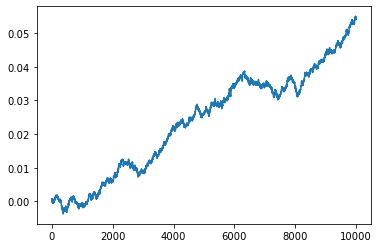

In [27]:
ax = plt.gca()
plt.plot(np.array(errs).cumsum())
plt.show()

In [10]:
np.unique([r["nShots"][-1] for r in results], return_counts=True)

(array([100, 200]), array([9373,  627], dtype=int64))

In [11]:
from BiasCorrection import BiasExact

In [12]:
biasesExact = [BiasExact(pTrue, r["nGrover"][-1], r["nShots"][-1]) for r in results]
print(np.mean(biasesExact))

-3.3904269194915915e-07


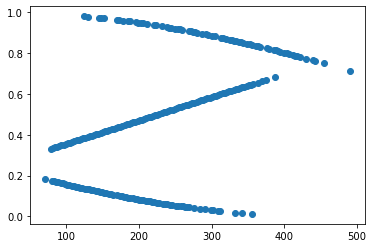

In [13]:
thetaTrue = np.arcsin(np.sqrt(pTrue))
nGVals = np.unique([r["nGrover"][-1] for r in results])
plt.scatter(nGVals, np.sin((2 * nGVals + 1) * thetaTrue) ** 2)

In [14]:
results_LastNShot100 = results[[r["nShots"][-1] == 100 for r in results]]
print(len(results_LastNShot100))

9373


-7.208210758312483e-07
7.3533587764885484e-06
1.5350049947885663e-06


(array([  0.,   2.,   0.,   0.,   0.,   2.,   0.,   2.,   0.,   0.,   3.,
          0.,   2.,   0.,   4.,   4.,   3.,   4.,   2.,   4.,   0.,   4.,
          2.,   5.,   6.,  19.,  51.,  10.,  67., 141., 137., 254., 181.,
        172., 237., 259., 278., 207., 286., 404., 344., 355., 288., 408.,
        434., 324., 399., 506., 473., 566., 606., 443., 502., 266.,  88.,
         13.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0., 103., 269.,  67.,  69.,  21.,  13.,  13.,  10.,   7.,
          5.]),
 array([-1.0e-05, -9.8e-06, -9.6e-06, -9.4e-06, -9.2e-06, -9.0e-06,
        -8.8e-06, -8.6e-06, -8.4e-06, -8.2e-06, -8.0e-06, -7.8e-06,
        -7.6e-06, -7.4e-06, -7.2e-06, -7.0e-06, -6.8e-06, -6.6e-06,
        -6.4e-06, -6.2e-06, -6.0e-06, -5.8e-06, -5.6e-06, -5.4e-06,
        -5.2e-06, -5.0e-06, -4.8e-06, -4.6e-06

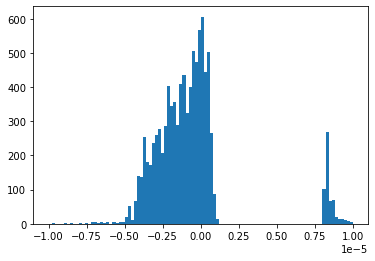

In [74]:
biases_LastNShot100 = [BiasCoxSnell(pTrue, r["nGrover"][-1], r["nShots"][-1]) for r in results_LastNShot100]    
print(np.mean(biases_LastNShot100))
errs_LastNShot100 = [r["Estimate"] - pTrue for r in results_LastNShot100]
print(np.mean(errs_LastNShot100))
print(np.std(errs_LastNShot100) / np.sqrt(len(results_LastNShot100)))
plt.hist(biases_LastNShot100, range=(-1e-5,1e-5), bins=100)

In [16]:
p1FinalErr_LastNShot100 = np.array([r["n1s"][-1] / r["nShots"][-1] - np.sin((2 * r["nGrover"][-1] + 1) * thetaTrue) ** 2 for r in results_LastNShot100])

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   2.,   1.,
         10.,  12.,  16.,  35.,  67.,  90., 155., 226., 269., 377., 505.,
        585., 690., 728., 795., 789., 741., 667., 631., 511., 397., 326.,
        260., 169., 111.,  90.,  60.,  25.,  17.,   9.,   3.,   3.,   1.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.]),
 array([-7.00000000e-01, -6.90000000e-01, -6.80000000e

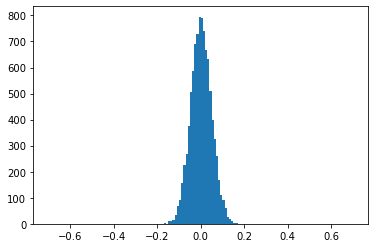

In [17]:
plt.hist(p1FinalErr_LastNShot100, range=(-0.7, 0.7), bins=140)

In [18]:
print(np.mean(p1FinalErr_LastNShot100))
print(np.std(p1FinalErr_LastNShot100) / np.sqrt(len(p1FinalErr_LastNShot100)))

0.001913331006482632
0.0004912785822731323


(array([  9., 242., 684., 467., 554., 722., 556., 501., 579., 484., 419.,
        509., 393., 367., 432., 282., 232., 377., 218., 204., 260., 159.,
        128., 169.,  96.,  49.,  92.,  38.,  32.,  18.,  22.,  20.,  13.,
         18.,  17.,   2.,   6.,   1.]),
 array([ 70.,  80.,  90., 100., 110., 120., 130., 140., 150., 160., 170.,
        180., 190., 200., 210., 220., 230., 240., 250., 260., 270., 280.,
        290., 300., 310., 320., 330., 340., 350., 360., 370., 380., 390.,
        400., 410., 420., 430., 440., 450.]),
 <BarContainer object of 38 artists>)

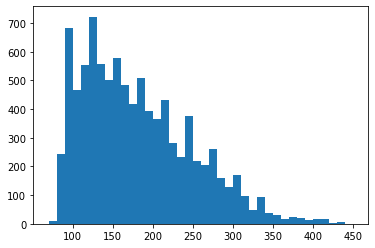

In [19]:
plt.hist([r["nGrover"][-1] for r in results_LastNShot100], range=(70, 450), bins=38)

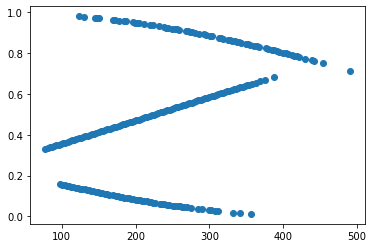

In [20]:
nGVals_LastNShot100 = np.unique([r["nGrover"][-1] for r in results_LastNShot100])
plt.scatter(nGVals_LastNShot100, np.sin((2 * nGVals_LastNShot100 + 1) * thetaTrue) ** 2)

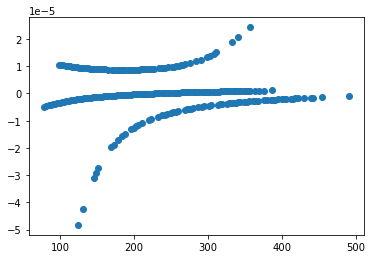

In [21]:
plt.scatter(nGVals_LastNShot100, [BiasExact(pTrue, nG, 100) for nG in nGVals_LastNShot100])

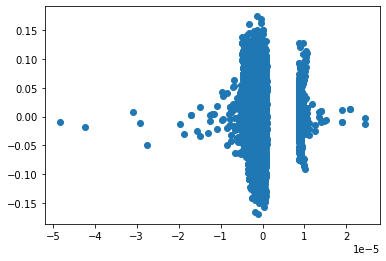

In [22]:
biasExact_LastNShot100 = np.array([BiasExact(pTrue, r["nGrover"][-1], 100) for r in results_LastNShot100])
plt.scatter(biasExact_LastNShot100, p1FinalErr_LastNShot100)

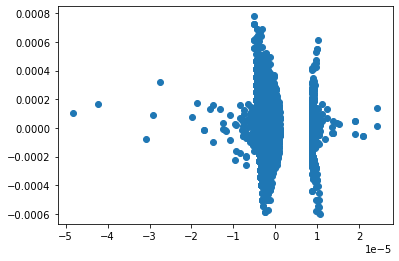

In [23]:
plt.scatter(biasExact_LastNShot100, errs_LastNShot100)

In [24]:
np.corrcoef(biasExact_LastNShot100, errs_LastNShot100)

array([[ 1.        , -0.06594478],
       [-0.06594478,  1.        ]])

In [25]:
p1Final_LastNShot100 = np.array([np.sin((2 * r["nGrover"][-1] + 1) * thetaTrue) ** 2 for r in results_LastNShot100])
p1FinalErr_LastNShot100_p1Lt03 = p1FinalErr_LastNShot100[p1Final_LastNShot100 < 0.3]
p1FinalErr_LastNShot100_p103To07 = p1FinalErr_LastNShot100[(0.3 <= p1Final_LastNShot100) & (p1Final_LastNShot100 < 0.7)]
p1FinalErr_LastNShot100_p1Gt07 = p1FinalErr_LastNShot100[0.7 <= p1Final_LastNShot100]
print(len(p1FinalErr_LastNShot100_p1Lt03), np.mean(p1FinalErr_LastNShot100_p1Lt03), np.std(p1FinalErr_LastNShot100_p1Lt03) / np.sqrt(len(p1FinalErr_LastNShot100_p1Lt03)))
print(len(p1FinalErr_LastNShot100_p103To07), np.mean(p1FinalErr_LastNShot100_p103To07), np.std(p1FinalErr_LastNShot100_p103To07) / np.sqrt(len(p1FinalErr_LastNShot100_p103To07)))
print(len(p1FinalErr_LastNShot100_p1Gt07), np.mean(p1FinalErr_LastNShot100_p1Gt07), np.std(p1FinalErr_LastNShot100_p1Gt07) / np.sqrt(len(p1FinalErr_LastNShot100_p1Gt07)))

589 0.0028682048919867423 0.0015735987461580538
8478 0.0019299411923370724 0.0005271422243564784
306 -0.00038484505311169807 0.001986742292869927


In [43]:
nGrov, cnt = np.unique([r["nGrover"][-1] for r in results_LastNShot100], return_counts=True)
df = pd.DataFrame({"nGrov": nGrov, "cnt":cnt})
df.sort_values('cnt', ascending=False)[:10]

,nGrov,cnt
16,111,271
24,123,266
5,93,247
10,102,230
51,156,199
34,135,195
18,114,192
22,120,189
32,132,186
87,201,176


In [40]:
results_LastNShot100NGrov111 = results_LastNShot100[[r["nGrover"][-1]==111 for r in results_LastNShot100]]
p1FinalErr_LastNShot100NGrov111 = p1FinalErr_LastNShot100[[r["nGrover"][-1]==111 for r in results_LastNShot100]]

In [41]:
print(len(p1FinalErr_LastNShot100NGrov111))
print(np.mean(p1FinalErr_LastNShot100NGrov111))
print(np.std(p1FinalErr_LastNShot100NGrov111) / np.sqrt(len(p1FinalErr_LastNShot100NGrov111)))

271
0.0010103686877055622
0.0029366009996221907


In [44]:
p1FinalErrMean = np.array([])
p1FinalErrSD = np.array([])
for nG in df["nGrov"]:
    p1FinalErr_specnGrov = p1FinalErr_LastNShot100[[r["nGrover"][-1]==nG for r in results_LastNShot100]]
    p1FinalErrMean = np.append(p1FinalErrMean, np.mean(p1FinalErr_specnGrov))
    p1FinalErrSD = np.append(p1FinalErrSD, np.std(p1FinalErr_specnGrov) / np.sqrt(len(p1FinalErr_specnGrov)))

df["p1FinalErrMean"] = p1FinalErrMean
df["p1FinalErrSD"] = p1FinalErrSD

In [47]:
df["p1FinalErrMean/p1FinalErrSD"] = p1FinalErrMean / p1FinalErrSD

<ipython-input-47-7c413c037594>:1: RuntimeWarning: divide by zero encountered in true_divide
  df["p1FinalErrMean/p1FinalErrSD"] = p1FinalErrMean / p1FinalErrSD


In [48]:
df[df["cnt"] > 100].sort_values("p1FinalErrMean/p1FinalErrSD")

,nGrov,cnt,p1FinalErrMean,p1FinalErrSD,p1FinalErrMean/p1FinalErrSD
64,174,153,-0.006834,0.004112,-1.662085
79,192,156,-0.005961,0.003802,-1.567597
110,228,103,-0.007399,0.004782,-1.547354
36,138,150,-0.005578,0.003897,-1.431399
32,132,186,-0.004801,0.003641,-1.318439
46,150,101,-0.004954,0.005357,-0.924831
71,183,106,-0.003591,0.004762,-0.754158
29,129,134,-0.003030,0.004047,-0.748613
69,180,175,-0.001456,0.003716,-0.391889
38,141,130,-0.001633,0.004231,-0.386021


In [50]:
errMean = np.array([])
errSD = np.array([])
errs_LastNShot100 = np.array(errs_LastNShot100)
for nG in df["nGrov"]:
    err_specnGrov = errs_LastNShot100[[r["nGrover"][-1]==nG for r in results_LastNShot100]]
    errMean = np.append(errMean, np.mean(err_specnGrov))
    errSD = np.append(errSD, np.std(err_specnGrov) / np.sqrt(len(err_specnGrov)))

df["errMean"] = errMean
df["errSD"] = errSD

In [51]:
df["errMean/errSD"] = np.abs(errMean) / errSD

<ipython-input-51-2008c881f62c>:1: RuntimeWarning: divide by zero encountered in true_divide
  df["errMean/errSD"] = np.abs(errMean) / errSD


In [53]:
df[df["cnt"] > 100].sort_values("errMean/errSD", ascending=False)

,nGrov,cnt,p1FinalErrMean,p1FinalErrSD,p1FinalErrMean/p1FinalErrSD,errMean,errSD,errMean/errSD
3,87,130,0.024809,0.002956,8.393419,1.268801e-04,0.000015,8.376635
4,90,122,0.011799,0.003536,3.336577,5.698796e-05,0.000018,3.239191
5,93,247,0.006757,0.002523,2.678258,3.047178e-05,0.000012,2.495911
105,222,105,0.009250,0.004869,1.899708,1.803923e-05,0.000010,1.893158
64,174,153,-0.006834,0.004112,-1.662085,-1.800562e-05,0.000010,1.738487
27,126,119,0.007772,0.004392,1.769682,2.548218e-05,0.000015,1.646794
79,192,156,-0.005961,0.003802,-1.567597,-1.392593e-05,0.000009,1.614096
36,138,150,-0.005578,0.003897,-1.431399,-1.944903e-05,0.000013,1.552659
110,228,103,-0.007399,0.004782,-1.547354,-1.407235e-05,0.000009,1.546048
22,120,189,0.005445,0.003312,1.643716,1.823340e-05,0.000012,1.480484


In [59]:
nGroverCntGt100 = np.unique(df[df["cnt"] > 100]["nGrov"])
errs_LastNShot100_nGroverCntGt100 = errs_LastNShot100[[np.isin(r["nGrover"][-1], nGroverCntGt100) for r in results_LastNShot100]]

In [60]:
np.mean(errs_LastNShot100_nGroverCntGt100)

6.395873430029599e-06

In [57]:
np.isin(3, [5,6,3,2])

array(True)

In [67]:
errs_LastNShot100_ExceptnGrover87 = errs_LastNShot100[[r["nGrover"][-1] != 87 for r in results_LastNShot100]]

In [68]:
np.mean(errs_LastNShot100_ExceptnGrover87)

5.67225153796641e-06

In [69]:
len(errs_LastNShot100_nGroverCntGt100)

5947

In [65]:
df["errMeanAbs"] = np.abs(df["errMean"])
df[df["cnt"] > 100].sort_values("errMean", ascending=False)

,nGrov,cnt,p1FinalErrMean,p1FinalErrSD,p1FinalErrMean/p1FinalErrSD,errMean,errSD,errMean/errSD,errMeanAbs
3,87,130,0.024809,0.002956,8.393419,1.268801e-04,0.000015,8.376635,1.268801e-04
4,90,122,0.011799,0.003536,3.336577,5.698796e-05,0.000018,3.239191,5.698796e-05
5,93,247,0.006757,0.002523,2.678258,3.047178e-05,0.000012,2.495911,3.047178e-05
27,126,119,0.007772,0.004392,1.769682,2.548218e-05,0.000015,1.646794,2.548218e-05
6,96,159,0.005382,0.003447,1.561484,2.253631e-05,0.000016,1.391943,2.253631e-05
22,120,189,0.005445,0.003312,1.643716,1.823340e-05,0.000012,1.480484,1.823340e-05
105,222,105,0.009250,0.004869,1.899708,1.803923e-05,0.000010,1.893158,1.803923e-05
24,123,266,0.004317,0.002906,1.485464,1.362114e-05,0.000011,1.294448,1.362114e-05
58,168,118,0.005484,0.004366,1.256115,1.347740e-05,0.000011,1.184858,1.347740e-05
51,156,199,0.004863,0.003691,1.317537,1.248837e-05,0.000010,1.201465,1.248837e-05


In [70]:
nGrovErrMeanTop5 = df[df["cnt"] > 100].sort_values("errMean", ascending=False)["nGrov"][:5]
print(nGrovErrMeanTop5)
errs_LastNShot100_ExceptErrTop5 = errs_LastNShot100[[not(np.isin(r["nGrover"][-1], nGrovErrMeanTop5)) for r in results_LastNShot100]]
print(np.mean(errs_LastNShot100_ExceptErrTop5))

3      87
4      90
5      93
27    126
6      96
Name: nGrov, dtype: int32
3.645172911676323e-06


In [71]:
nGrovErrMeanTop10 = df[df["cnt"] > 100].sort_values("errMean", ascending=False)["nGrov"][:10]
print(nGrovErrMeanTop10)
errs_LastNShot100_ExceptErrTop10 = errs_LastNShot100[[not(np.isin(r["nGrover"][-1], nGrovErrMeanTop10)) for r in results_LastNShot100]]
print(np.mean(errs_LastNShot100_ExceptErrTop10))

3       87
4       90
5       93
27     126
6       96
22     120
105    222
24     123
58     168
51     156
Name: nGrov, dtype: int32
2.370116908964335e-06


In [89]:
pd.options.display.float_format = '{:.4e}'.format

In [93]:
df["BiasExact"] = np.zeros(len(df))
for i in range(len(df)):
    df.loc[i, "BiasExact"] = BiasExact(pTrue, df.loc[i,"nGrov"], 100)
df[df["cnt"] > 100].sort_values("errMean", ascending=False)

,nGrov,cnt,p1FinalErrMean,p1FinalErrSD,p1FinalErrMean/p1FinalErrSD,errMean,errSD,errMean/errSD,errMeanAbs,BiasExact
3,87,130,2.4809e-02,2.9557e-03,8.3934e+00,1.2688e-04,1.5147e-05,8.3766e+00,1.2688e-04,-4.1595e-06
4,90,122,1.1799e-02,3.5364e-03,3.3366e+00,5.6988e-05,1.7593e-05,3.2392e+00,5.6988e-05,-3.9289e-06
5,93,247,6.7572e-03,2.5230e-03,2.6783e+00,3.0472e-05,1.2209e-05,2.4959e+00,3.0472e-05,-3.7136e-06
27,126,119,7.7717e-03,4.3916e-03,1.7697e+00,2.5482e-05,1.5474e-05,1.6468e+00,2.5482e-05,-2.0345e-06
6,96,159,5.3824e-03,3.4470e-03,1.5615e+00,2.2536e-05,1.6191e-05,1.3919e+00,2.2536e-05,-3.5119e-06
22,120,189,5.4446e-03,3.3124e-03,1.6437e+00,1.8233e-05,1.2316e-05,1.4805e+00,1.8233e-05,-2.2693e-06
105,222,105,9.2497e-03,4.8690e-03,1.8997e+00,1.8039e-05,9.5286e-06,1.8932e+00,1.8039e-05,-4.2763e-08
24,123,266,4.3173e-03,2.9063e-03,1.4855e+00,1.3621e-05,1.0523e-05,1.2944e+00,1.3621e-05,-2.1490e-06
58,168,118,5.4839e-03,4.3658e-03,1.2561e+00,1.3477e-05,1.1375e-05,1.1849e+00,1.3477e-05,-8.7398e-07
51,156,199,4.8635e-03,3.6913e-03,1.3175e+00,1.2488e-05,1.0394e-05,1.2015e+00,1.2488e-05,-1.1396e-06


In [94]:
from IQAEBinom_OnlyFinalRound import IQAEBinom_OnlyFinalRound

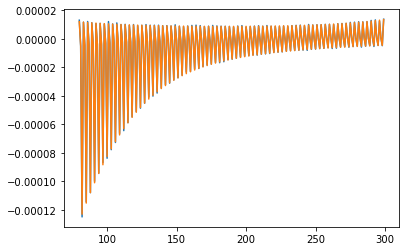

In [101]:
nGs = np.arange(80, 300)
errMean_onlyFinal = np.array([])
biasExact = np.array([])
for nG in nGs:
    estims = np.array([])
    for _ in range(100000):
        estim = IQAEBinom_OnlyFinalRound(pTrue, nG, 100)
        estims = np.append(estims, estim)
    errMean_onlyFinal = np.append(errMean_onlyFinal, np.mean(estims - pTrue))
    biasExact = np.append(biasExact, BiasExact(pTrue, nG, 100))

ax = plt.gca()
plt.plot(nGs, errMean_onlyFinal, label="ErrMean")
plt.plot(nGs, biasExact, label="BiasExact")
plt.show()

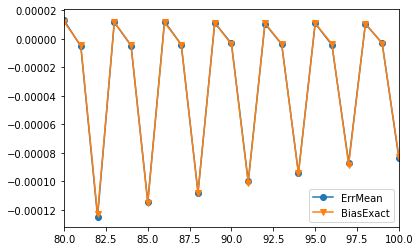

In [109]:
ax = plt.gca()
plt.plot(nGs, errMean_onlyFinal, label="ErrMean", marker="o")
plt.plot(nGs, biasExact, label="BiasExact", marker="v")
ax.set_xlim(80, 100)
ax.legend()
plt.show()

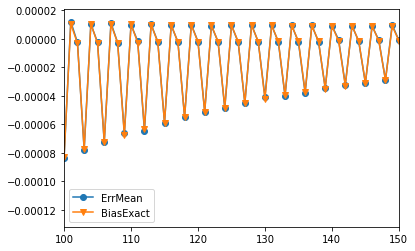

In [110]:
ax = plt.gca()
plt.plot(nGs, errMean_onlyFinal, label="ErrMean", marker="o")
plt.plot(nGs, biasExact, label="BiasExact", marker="v")
ax.set_xlim(100, 150)
ax.legend()
plt.show()

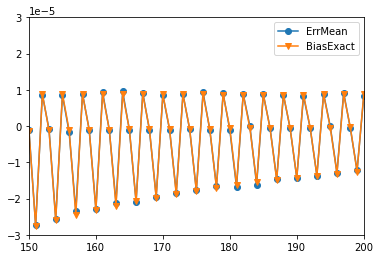

In [111]:
ax = plt.gca()
plt.plot(nGs, errMean_onlyFinal, label="ErrMean", marker="o")
plt.plot(nGs, biasExact, label="BiasExact", marker="v")
ax.set_xlim(150, 200)
ax.set_ylim(-3e-5, 3e-5)
ax.legend()
plt.show()

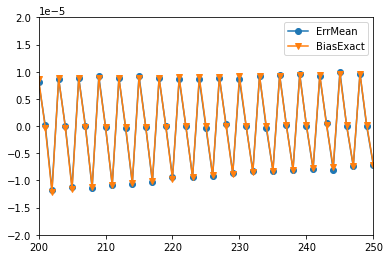

In [112]:
ax = plt.gca()
plt.plot(nGs, errMean_onlyFinal, label="ErrMean", marker="o")
plt.plot(nGs, biasExact, label="BiasExact", marker="v")
ax.set_xlim(200, 250)
ax.set_ylim(-2e-5, 2e-5)
ax.legend()
plt.show()

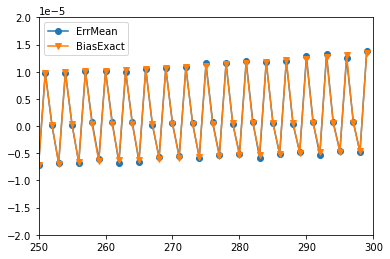

In [114]:
ax = plt.gca()
plt.plot(nGs, errMean_onlyFinal, label="ErrMean", marker="o")
plt.plot(nGs, biasExact, label="BiasExact", marker="v")
ax.set_xlim(250, 300)
ax.set_ylim(-2e-5, 2e-5)
ax.legend()
plt.show()